# Practical session 4 - K-nearest neighbours (K-NN) classification with numpy, scikit-learn, cython and numba

Students (pair):
- [Henry Fernandes--Strag](https://github.com/hfstrag)
- [Alexandre Torres--Leguet]([link](https://github.com/alxndrTL))

GitHub project where we collaborate: https://github.com/alxndrTL/python_sdia

**Useful references for this lab**:

[1] scikit-learn: [documentation](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification)

[2] `numba`: [documentation](http://numba.pydata.org/) 

[3] cython: [a very useful tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), and [another one](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html)



## <a name="content">Contents</a>
- [Exercise 1: KNN classification with numpy and sklearn](#ex1)
- [Exercise 2: Code acceleration with cython](#ex2)
- [Exercise 3: Code acceleration with numba](#ex3)
---

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import numpy as np
import matplotlib.pyplot as plt

import bottleneck as bn

## <a name="ex1">Exercise 1: K-Nearest Neighbours (K-NN) classification with numpy and scikit-learn</a> [(&#8593;)](#content)

This session is a first introduction to classification using the most intuitive non parametric method: the $K$-nearest neighbours. The principle is [the following](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification). A set of labelled observations is given as a learning set. A classification taks then consists in assigning a label to any new observation. In particular, the K-NN approach consists in assigning to the observation the most frequent label among its $K$ nearest neighbours taken in the training set.

### A. Validation on synthetic data

Load the training and test datasets `data/synth_train.txt` and `data/synth_test.txt`. Targets belong to the set $\{1,2\}$ and entries belong to $\mathbb{R}^2$. The file `data/synth_train.txt` contain 100 training data samples, and `data/synth_test.txt` contains 200 test samples, where:

- the 1st column contains the label of the class the sample;
- columns 2 & 3 contain the coordinates of each sample (in $\mathbb{R}^2$).

Useful commands can be found below.

```python
# load the training set
train = np.loadtxt('data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]
```

```python
# load the test set
test = np.loadtxt('/datasynth_test.txt') 
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]
```

1\. Display the training set and distinguish the two classes. 

> Hint: useful functions include `matplotlib.pyplot.scatter` or `matplotlib.pyplot.plot`.

**Answer:**

In [29]:
# load the training set
train = np.loadtxt('data/synth_train.txt')
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]

# load the test set
test = np.loadtxt('data/synth_test.txt')
class_test = test[:,0]
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]

Text(0.5, 1.0, 'Points du training set')

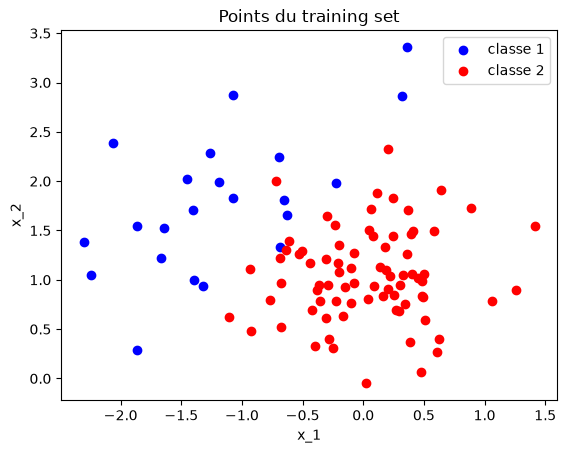

In [30]:
plt.scatter(x_train[class_train==1, 0], x_train[class_train==1, 1], color='blue', label='classe 1')
plt.scatter(x_train[class_train==2, 0], x_train[class_train==2, 1], color='red', label='classe 2')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.title('Points du training set')

2\. Implement the K-nearest neighbours algorithm for classification.

> Hint: 
> - useful functions include `numpy.linalg.norm`, `numpy.argsort`, `numpy.bincount`;
> - implement the algorithm as a function rather than an object. This will drastically simplify the acceleration step using Cython.
> - for an optimized partial sorting procedure, you may have a look at the [`bottleneck.argpartition` function](https://bottleneck.readthedocs.io/en/latest/reference.html#bottleneck.argpartition).
> 1. Compute for each row in `x_test` (if necessary use `np.newaxis`) its distance with respect to `x_train`:
>  - Use  `numpy.linalg.norm` (in which dimension this distance is computed ? Consider using `axis` argument)
> 2. Sort the ordered collection of distances (indices from smallest to largest (in ascending order) by the distances):
>   - Use `np.argsort` (at the end replace this procedure by `bottleneck.argpartition`)
>   - Once the sorting is done, we take only the indices of `labels` of the `n_neighbours` nearest neighbours of the `class_train` :
>     - `id = np.argsort(distances)[:n_ neighbours]` and `labels = class_train[id]`
> 3. The K-nearest can be used for **Regression**, in this case it is necessary to return the mean of the K-labels. For **Classification**,  we return the mode of the K-labels :
> - Use `np.bincount` for `labels` to affect the variable `class_pred[q]` (for row `q`). This procedure counts the number of occurrences of each value in array. **Mode** is the value that appears. How can we get this value ?


```python
import numpy as np
import bottleneck as bn

# Create a random array
arr = np.random.rand(10)
N = 3  # Number of smallest elements to retrieve

# Using np.argsort() to get indices of the first N elements
sorted_indices = np.argsort(arr)[:N]

# Using bottleneck.argpartition() to get the first N smallest indices
partitioned_indices = bn.argpartition(arr, N)[:N]

# Display the results
print("Original array:", arr)
print("Indices using np.argsort:", sorted_indices)
print("First N elements using np.argsort:", arr[sorted_indices])

print("Indices using bottleneck.argpartition:", partitioned_indices)
print("First N elements using bottleneck.argpartition:", arr[partitioned_indices])

are_equal = set(arr[sorted_indices]) == set(arr[partitioned_indices])
print(are_equal)
```


**Answer:**

In [31]:
# tests pour comprendre le fonctionnement de bottleneck.argpartition

l = np.array([11, 10, 14, 12, 13])

print('liste : ', l)
print('trié :', np.sort(l))

for k in range(len(l)):
    v = l[bn.argpartition(l, k)]
    print(k, v[:k])

# conclusion : bottleneck.argpartition(l, k)[:k+1] renvoie les indices des k+1 plus petits éléments de l (pas forcément dans l'ordre)
# c'est donc ce qu'on veut pour knn puisqu'on a seulement besoin de savoir quels sont les k plus proches points

liste :  [11 10 14 12 13]
trié : [10 11 12 13 14]
0 []
1 [10]
2 [11 10]
3 [11 10 12]
4 [11 10 13 12]


In [32]:
# tests pour comprendre bincount

print(np.bincount([0, 0, 1, 2, 1, 1, 2, 3]))

print(np.argmax(np.bincount([0, 0, 1, 2, 1, 1, 2, 3]))) # c'est bien la classe 1 la plus présente

# conclusion : bincount renvoie le nombre d'occurrences de chaque entier dans la liste, on fait un argmax dessus pour récuperer l'entier/la classe la plus présente

[2 3 2 1]
1


In [33]:
def knn(x_train, class_train, x_test, n_neighbours=3):
    """Algorithme des K plus proches voisins
 
    x_train      : (N_train, d)
    class_train  : (N_train,)
    x_test       : (N_test, d)
    n_neighbours : K
    Returns class_pred : (N_test,) predicted labels
    """
    
    class_train = class_train.astype(int)
    N_test = x_test.shape[0]
    class_pred = np.zeros(N_test, dtype=int)
 
    for q in range(N_test):
        # distance de "q" avec tous les points du training set
        # on calcule pour ça la norme de x_train-q, qui par broadcast correspond à la matrice
        # (x_train_1 - q, ..., x_train_N - q)
        # donc calculer la norme de chaque ligne de cette matrice nous donne les distances
        distances = np.linalg.norm(x_train - x_test[q], axis=1)
 
        # indices des K plus petites distances
        idx = bn.argpartition(distances, n_neighbours - 1)[:n_neighbours] # indices des K plus proches voisins
        labels = class_train[idx] # on récupère les labels de ces points voisins
 
        # vote majoritaire parmis "labels" = c'est notre prédiction
        class_pred[q] = np.argmax(np.bincount(labels))
        # (for regression you would return labels.mean() instead)
 
    return class_pred

3\. Compute the error rate on the training set and the test set for $K \in \{1,2, \dotsc, 20\}$. Display the classification result (see 1.) for the configuration with the lowest error rate.

**Answer:**

In [34]:
def accuracy(pred, truth):
    """Calcule l'exactitude des prédictions"""
    assert pred.shape == truth.shape, "le vecteur des prédictions doit avoir la même taille que le vecteur des étiquettes"
    return np.mean(pred == truth)

Ks = np.arange(1, 21)

accuracies_train = []
accuracies_test = []

for K in Ks:
    class_pred = knn(x_train, class_train, x_train, K)
    acc_train = accuracy(class_pred, class_train)
    
    class_pred = knn(x_train, class_train, x_test, K)
    acc_test = accuracy(class_pred, class_test)

    accuracies_train.append(acc_train)
    accuracies_test.append(acc_test)

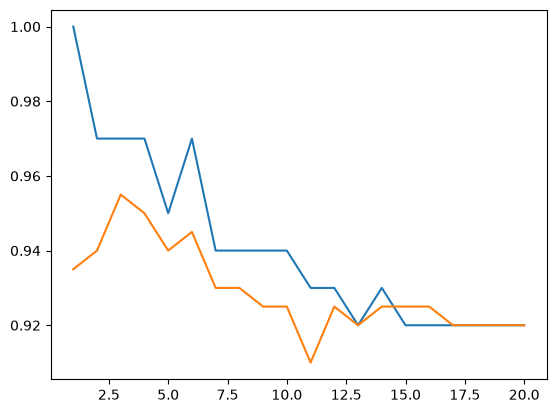

In [35]:
plt.plot(Ks, accuracies_train, label='train')
plt.plot(Ks, accuracies_test, label='test')

In [36]:
# la meilleure configuration pour le test set est avec K=3

In [37]:
# tests avec meshgrid pour plot le decision boundary (utilisé dans la cellule suivante)
# inspiré de la solution trouvée dans https://stackoverflow.com/questions/28256058/plotting-decision-boundary-of-logistic-regression

linspace1 = np.array([0,   1, 2])
linspace2 = np.array([10, 20, 30])

xx1, xx2 = np.meshgrid(linspace1, linspace2) # (N, N) x 2 : permet de quadriller l'espace x1-x2 avec N*N points
print(xx1) # coordonnées x1 des points du quadrillage
print(xx2) # coordonnées x2 des points du quadrillage

print(xx1.flatten())
print(xx2.flatten())

print(np.column_stack([xx1.flatten(), xx2.flatten()])) # permet de reconstituer (x1, x2) des points du quadrillage

[[0 1 2]
 [0 1 2]
 [0 1 2]]
[[10 10 10]
 [20 20 20]
 [30 30 30]]
[0 1 2 0 1 2 0 1 2]
[10 10 10 20 20 20 30 30 30]
[[ 0 10]
 [ 1 10]
 [ 2 10]
 [ 0 20]
 [ 1 20]
 [ 2 20]
 [ 0 30]
 [ 1 30]
 [ 2 30]]


Text(0.5, 1.0, 'Points du training set et zone de décision pour K=3 (accuracy test=0.95)')

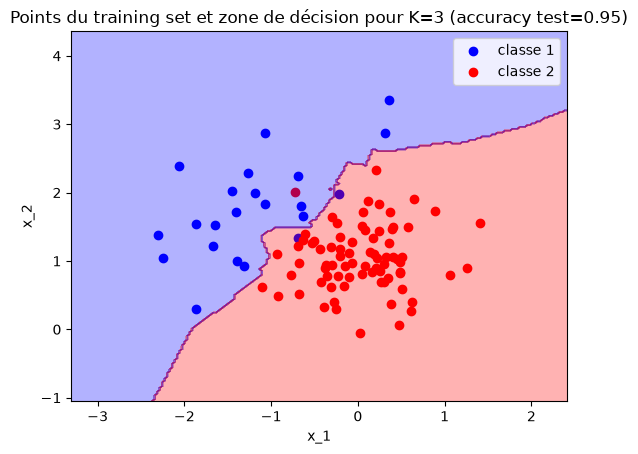

In [38]:
# on plot le decision boundary pour K=3
K = 3
class_pred = knn(x_train, class_train, x_test, K)
acc_test = accuracy(class_pred, class_test)

# affichage des points du dataset
plt.scatter(x_train[class_train==1, 0], x_train[class_train==1, 1], color='blue', label='classe 1')
plt.scatter(x_train[class_train==2, 0], x_train[class_train==2, 1], color='red', label='classe 2')

# affichage du decision boundary
N = 200
linspace1 = np.linspace(x_train[:,0].min()-1, x_train[:,0].max()+1, N) # (N,) : linspace pour x1
linspace2 = np.linspace(x_train[:,1].min()-1, x_train[:,1].max()+1, N) # (N,) : linspace pour x2
xx1, xx2 = np.meshgrid(linspace1, linspace2) # (N, N) x 2 : permet de quadriller l'espace x1-x2 avec N*N points

Z = knn(x_train, class_train, np.column_stack([xx1.flatten(), xx2.flatten()]), K).reshape(xx1.shape)

plt.contourf(xx1, xx2, Z, alpha=0.3, colors=['blue', 'red'])

plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.title(f'Points du training set et zone de décision pour K={K} (accuracy test={acc_test:.2f})')

4\. Comment on your results. Which value of $K$ seems optimal ?


**Answer:**

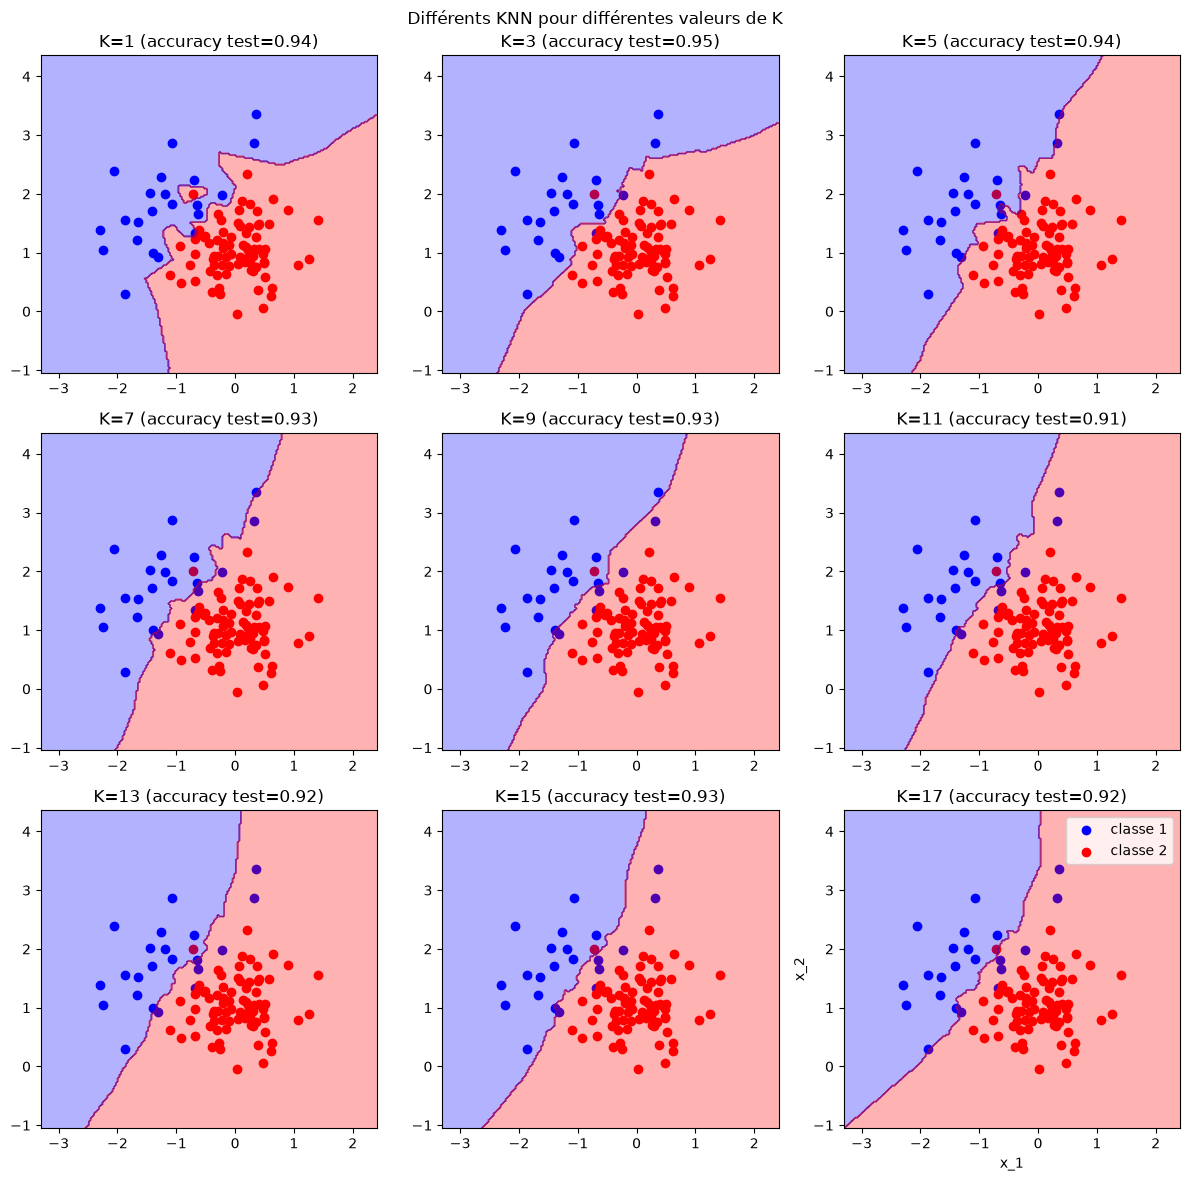

In [39]:
# on répète le plot précédent pour différentes valeurs de K, pour voir son influence sur la prédiction du modèle
# pour cela, on l'englobe dans une boucle (une pour chaque valeur de K testée) et on affiche les résultats dans une grille de sous-figures

Ks = np.arange(1, 19, 2) # les K qu'on teste
fig, axes = plt.subplots(3, 3, figsize=(12, 12)) # les 3x3 sous-figures

# code commun déplacé hors de la boucle
N = 200
linspace1 = np.linspace(x_train[:,0].min()-1, x_train[:,0].max()+1, N) # (N,) : linspace pour x1
linspace2 = np.linspace(x_train[:,1].min()-1, x_train[:,1].max()+1, N) # (N,) : linspace pour x2
xx1, xx2 = np.meshgrid(linspace1, linspace2) # (N, N) x 2 : permet de quadriller l'espace x1-x2 avec N*N points

for ax, K in zip(axes.flat, Ks):
    class_pred = knn(x_train, class_train, x_test, K)
    acc_test = accuracy(class_pred, class_test)

    # affichage des points du dataset
    ax.scatter(x_train[class_train==1, 0], x_train[class_train==1, 1], color='blue', label='classe 1')
    ax.scatter(x_train[class_train==2, 0], x_train[class_train==2, 1], color='red', label='classe 2')

    # affichage du decision boundary
    Z = knn(x_train, class_train, np.column_stack([xx1.flatten(), xx2.flatten()]), K).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.3, colors=['blue', 'red'])

    ax.set_title(f'K={K} (accuracy test={acc_test:.2f})')

plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
fig.suptitle(f'Différents KNN pour différentes valeurs de K')
plt.tight_layout()

La valeur de K optimale semble être 3 (cf graphique de la question précédente). Ici, on visualise les prédictions des différents KNN en fonction de K. Un K petit (typiquement 1) possède un faible biais mais une haute variance : il y a sur-apprentissage. Donc les performances sur les données tests sont moins bonnes (le modèle généralise moins bien). Au contraire, une haute valeur de K réduit la variance mais augmente le biais : le modèle rate même la classification de points du training set. Le bon compromis est trouvé pour K=3.

5\. Compare the results of you implementation with those of [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=kneighborsclassifier#sklearn.neighbors.KNeighborsClassifier). Compare the runtime of these two versions using the [`timeit`](https://docs.python.org/3/library/timeit.html) module (see session 1).

**Answer:**

In [40]:
from sklearn.neighbors import KNeighborsClassifier

K = 3

# équivalence numérique avec notre version
knn_sklearn = KNeighborsClassifier(n_neighbors=K)
knn_sklearn.fit(x_train, class_train)

print("score knn de sklearn :")
print(knn_sklearn.score(x_test, class_test))

class_pred = knn(x_train, class_train, x_test, K)
acc_test = accuracy(class_pred, class_test)
print("score de notre propre knn :")
print(acc_test)

score knn de sklearn :
0.955
score de notre propre knn :
0.955


In [42]:
# performance
print("Runtime de notre knn :")
%timeit knn(x_train, class_train, x_test, 3)

print("Runtime de knn de sklearn :")
%timeit knn_sklearn.fit(x_train, class_train); knn_sklearn.predict(x_test)

Runtime de notre knn :
704 μs ± 6.84 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Runtime de knn de sklearn :
457 μs ± 3.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [43]:
# avec des datasets plus grands:
N = 10000
X_train = np.random.rand(N, 2)
y_train = np.random.randint(0, 2, N)
X_test = np.random.rand(N, 2)

%timeit knn(X_train, y_train, X_test, 3)
%timeit knn_sklearn.fit(X_train, y_train); knn_sklearn.predict(X_test)

1.36 s ± 12.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
6.68 ms ± 21.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


En terme de qualité, on retrouve bien, pour K=3, la même performance sur les données test que notre implémentation.

En terme de rapidité en revanche, la solution de scikit-learn est environ 2x plus rapide que notre version pour des petits datasets. Pour des datasets plus gros (10 000 exemples), l'écart est encore plus grand avec notre version.

### B. Application to a real dataset (Breast cancer Wisconsin).

6\. Apply the K-NN classifier to the real dataset `data/wdbc12.data.txt.` Further details about the data are provided in `data/wdbc12.names.txt`.

> Hint: you can use the function [`train_test_split` from `sklearn.model_selection`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to split the dataset into a training and a test set.

**Answer:**

In [24]:
# load the training set
dataset = np.loadtxt('data/wdbc12.data.txt', delimiter=',')

# l'attribut 0 est un ID, qui n'est pas une feature donc on l'exclue
# on récupère la classe (sain / malade) en attribut 1
# le reste = les features
y = dataset[:,1]
X = dataset[:,2:]
N = dataset.shape[0]

print(X.shape, y.shape) # 569 exemples, en dimension 30, avec 2 classes (sain / malade)

(569, 30) (569,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# nombre de positifs et négatifs dans le training set
print("nombre de positifs : ", np.sum(y_train==1))
print("nombre de négatifs : ", np.sum(y_train==2))

(455, 30) (455,)
(114, 30) (114,)
nombre de positifs :  169
nombre de négatifs :  286


In [27]:
K = 11 # trouvée par tatonnement

y_pred = knn(X_train, y_train, X_train, K)
acc_train = accuracy(y_pred, y_train)

y_pred = knn(X_train, y_train, X_test, K)
acc_test = accuracy(y_pred, y_test)

print(f"accuracy train : {acc_train:.2f}")
print(f"accuracy test : {acc_test:.2f}")

accuracy train : 0.93
accuracy test : 0.98


On obtient une accuracy de 98% sur les données tests. Cela veut dire qu'on arrive à prédire correctement dans 98% si une tumeur est bénigne ou maligne. Ce nombre n'est pas à comparer avec 50% car dans ce cas, le dataset n'est pas équilibré (il est composé à 63% de tumeurs bénignes). Donc un predicteur aléatoire qui prédit toujours "bénin" obtiendrait 63% et non 50%. 98% reste donc un bon score.

## <a name="ex2">Exercise 2: Code acceleration with cython</a> [(&#8593;)](#content)

Cython allows C code to be easily interfaced with Python. It can be useful to make your code faster for a small coding effort, in particular when using loops. A general approach to optimize your code is outlined in the [Scipy lecture notes, Section 2.4](https://scipy-lectures.org/advanced/optimizing/index.html). Complementary reading about interfacing Python with C can be found in [Section 2.8](https://scipy-lectures.org/advanced/interfacing_with_c/interfacing_with_c.html).

1\. Read carefully the [cython tutorial](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html), which describes step by the step how the toy example reported below has been developed.

**Setup**: Compile the toy example provided in `example_cy/` by running, in the command line (anaconda prompt on windows)

```bash
cd example_cy && python setup.py build_ext --inplace
```

Note that the compilation process has been slightly automatised with the instructions reported in `example_cy/setup.py`. To test the module, run

In [13]:
!cd example_cy && python setup.py build_ext --inplace

running build_ext


In [140]:
import example_cy.helloworld as toy

toy.printhello()

Hello World


which should display
```python
Hello World
```

> Warning: 
> - do not forget to include an empty `__init__.py` file in the directory where your source code lives (`import` will fail if this is not the case).
> - in case you have any setup issue, take a look at the `notes.md` file.
> - if the C code and/or the executable do not seem to be regenerated by the build instructions, delete the C code and the executable first, and re-execute the compilation afterwards.
> - do not hesitate to restart the Python kernel if necessary when the Cython executable has been re-generated.

2\. Read the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), focussing on the paragraphs **Cython at a glance**, and **Your Cython environment** until **"More generic code"**. An example to compile a `.pyx` file depending on `numpy` is included in `example_np_cy/`.

> Remarks: 
> - the `annotate=True` flag in the `setup.py` allows an additional `.html` document to be generated (`<your_module_name>.html`), showing, for each line of the Cython code, the associated C instructions generated. Highlighted in yellow are the interactions with Python: the darker a region appears, the less efficient the generated C code is for this section. Work in priority on these! 
> - make sure all the previously generated files are deleted to allow the .html report to be generated;
> - if you are working on your own machine and don't have a C/C++ compiler installed, read the notes provided in `notes.md`;
> - use `cdef` for pure C functions (not exported to Python), `cpdef` should be favored for functions containing C instructions and later called from Python.

**Answer:**

Nous lisons la documentation de Cython. Notamment, on inspecte le .html généré automatiquement par la précédente compilation (helloword.html).

3\. Use Cython to implement a faster version of the numpy K-NN classifier implemented in [Exercise 1](#ex1). To do so, apply step-by-step the techniques introduced in the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial) (*i.e.*, compile and time your code after each step to report the evolution, keeping track of the different versions of the cython function).

> Hint: if you keep numpy arrays, make sure you use memory views (see numpy/cython tutorial) to access the elements within it. Be extremely careful with the type of the input arrays (you may need to recast the format of the input elements before entering the function. The `numpy.asarray` function can prove useful).

> **Detailed guidelines**: a few notes and *caveat* to help you re-writing your code in cython:
> - try to reduce the number of calls to numpy instructions as much as possible;
> - **you do not have to optimize everything**. For the KNN function above, most of the time is spent in computing euclidean distances: you can thus focus on optimizing tihs operations by explicitly writing a for loop, which will ensure a minimal interaction with numpy when generating the associated C code at compilation. Calls to other numpy functions can be kept as-is;
> - if you need to create an array within the cython function, used np.zeros (**do NOT use python lists**), and use a memory view to access its content;
> - specify the type for all variables and numpy arrays. Pay attention to the type of the input arrays passed to the Cython function;
> - whenever an array is returned, use memory views and index(es) to efficiently access its content;
> - some numpy operators (e.g., broadcasting mechanism) do not work with memory views. In this case, you can directly write for loop(s) to encode the operation of interest (the loops will be optimized out at compile time);
> - only use at the final development stage the following cython optimization (not before, as they can crash the program without any help):
>
>```python
>@cython.boundscheck(False)
>@cython.wraparound(False)
>```

In [ ]:
# (on redemarre souvent le notebook, donc on place le code qu'on re-execute à chaque démarrage ici)

import numpy as np

from src.lab4_fns import knn
from sklearn.neighbors import KNeighborsClassifier

K = 3

# load the training set
train = np.loadtxt('data/synth_train.txt')
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]

# load the test set
test = np.loadtxt('data/synth_test.txt')
class_test = test[:,0]
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]

y_pred_python = knn(x_train, class_train, x_test, K)

**Answer:**

In [2]:
!cd knn_cy && python setup.py build_ext --inplace

Compiling knn3.pyx because it changed.
[1/1] Cythonizing knn3.pyx
running build_ext
building 'knn3' extension
gcc -fno-strict-overflow -Wsign-compare -Wunreachable-code -fno-common -dynamic -DNDEBUG -g -O3 -Wall -I/Users/alexandre/Desktop/inge/G3/python/.venv/include -I/opt/homebrew/opt/python@3.14/Frameworks/Python.framework/Versions/3.14/include/python3.14 -c knn3.c -o build/temp.macosx-26.0-arm64-cpython-314/knn3.o
knn3.c:23214:50: warning: code will never be executed
      [-Wunreachable-code]
 23214 |     if (unlikely(__Pyx_PyUnicode_READY(s1) < 0)) goto bad;
       |                                                  ^~~~~~~~
1 warning generated.
gcc -bundle -undefined dynamic_lookup build/temp.macosx-26.0-arm64-cpython-314/knn3.o -o build/lib.macosx-26.0-arm64-cpython-314/knn3.cpython-314-darwin.so
copying build/lib.macosx-26.0-arm64-cpython-314/knn3.cpython-314-darwin.so -> 


In [3]:
# premiere version : on s'entraîne à coder en cython en écrivant le kernel qui calcule A + alpha * B
# où A et B sont 2 matrices 2-2 et alpha un scalaire

import knn_cy.knn1 as knn_cython1

A = np.array([[1, 2], [3, 4], [5, 6]])
B = np.array([[7, 8], [9, 10], [11, 12]])
alpha = 2

res = knn_cython1.compute(A, B, alpha)
assert np.array_equal(res, A + alpha * B)

In [4]:
# KNN 2 : on traduit notre algorithme écrit en python
# la partie vraiment modifiée est celle du calcul des distances car on n'a plus accès au broadcasting
# donc on écrit une boucle sur N_train et sur le nombre de dimensions pour calculer chaque distance
# on fait attention à bien définir toutes les variables qu'on utilise en amont via cdef (même les itérateurs de boucle)

import knn_cy.knn2 as knn_cython2

y_pred_cython = knn_cython2.knn(x_train, class_train, x_test, K)
assert np.array_equal(y_pred_python, y_pred_cython) # on a bien équivalence numérique avec la version python

In [ ]:
print("Temps d'exécution de knn (python) :")
%timeit knn(x_train, class_train, x_test, K)

print("Temps d'exécution de knn (cython) :")
%timeit knn_cython2.knn(x_train, class_train, x_test, K)

Temps d'exécution de knn (python) :
677 μs ± 11.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Temps d'exécution de knn (cython) :
196 μs ± 1.78 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
# on est déjà 3x plus rapide que notre version python!

In [5]:
# deuxième version, avec 2 améliorations :
# on calcule le carré des distances (appliquer la racine ne sert à rien pour trier les distances)
# on passe les tableaux en mémoire contiguë pour que cython puisse y accéder plus rapidement

import knn_cy.knn3 as knn_cython3

y_pred_cython = knn_cython3.knn(x_train, class_train, x_test, K)
assert np.array_equal(y_pred_python, y_pred_cython)

In [ ]:
print("Temps d'exécution de knn (python) :")
%timeit knn(x_train, class_train, x_test, K)

print("Temps d'exécution de knn (cython) :")
%timeit knn_cython3.knn(x_train, class_train, x_test, K)

Temps d'exécution de knn (python) :
696 μs ± 9.09 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Temps d'exécution de knn (cython) :
194 μs ± 1.17 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [16]:
# knn3 est seulement environ 1% plus rapide que knn2..

4\. Compare the runtime of the two algorithms (using `timeit.timeit`), and conclude about the interest of using cython in this case.

**Answer:**

In [ ]:
# comparaisons entre nos versions sur un gros dataset:

K = 3
N = 10000
X_train = np.random.rand(N, 2)
y_train = np.random.randint(0, 2, N)
X_test = np.random.rand(N, 2)

knn_sklearn = KNeighborsClassifier(n_neighbors=K)

print("Temps d'exécution de knn (python) :")
%timeit knn(X_train, y_train, X_test, K)

print("Temps d'exécution de knn2 (cython) :")
%timeit knn_cython2.knn(X_train, y_train, X_test, K)

print("Temps d'exécution de knn3 (cython) :")
%timeit knn_cython3.knn(X_train, y_train, X_test, K)

print("Temps d'exécution de knn de sklearn (kdtree) :")
%timeit knn_sklearn.fit(X_train, y_train); knn_sklearn_kdtree.predict(X_test)

Temps d'exécution de knn (python) :
1.35 s ± 9.93 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Temps d'exécution de knn2 (cython) :
609 ms ± 9.13 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Temps d'exécution de knn3 (cython) :
571 ms ± 6.64 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Temps d'exécution de knn de sklearn (kdtree) :
6.53 ms ± 300 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Temps d'exécution de knn de sklearn (brute) :
20.5 ms ± 1.01 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [11]:
# On remarque que : 
# knn2 est 2x plus rapide que la version python, knn3 est 2,3x plus rapide que la version python
# knn3 est ici 6% plus rapide que knn2
# mais nous sommes encore loin derrière sklearn

# après recherche sur internet, il semble que la version de skelearn range les points dans des arbres
# ce qui lui évite de calculer toutes les distances

# pour améliorer notre KNN Cython, on pourrait :
# -reprendre la version de sklearn qui range les points dans des arbres
# -ou bien améliorer la seconde partie (qui utilise bottleneck et bincount) en la réécrivant en Cython

## <a name="ex3">Exercise 3: Code acceleration with numba</a> [(&#8593;)](#content)

`numba` is a just-in-time (JIT) compiler which translates Python codes into efficient machine code at runtime. A significant acceleration can be obtained by adding a few simple decorators to a standard Python function, up to a few restrictions detailed [here](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html).

If you have written most of the KNN classifier of exercise 1 with numpy, there is little to no chance that you will get an acceleration with numba (justifying the use of cython in this case). An interesting acceleration factor can however be obtained for the computation of the total variation investigated in session 2.

1\. Take a look at the [numba 5 min tour](http://numba.pydata.org/numba-doc/latest/user/5minguide.html), and accelerate the total variation code from session 2 with the `@jit` decorator. You may have to rewrite small portions of your code to get the expected acceleration (see [performance tips](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html)).

**Answer:**

In [14]:
from numba import njit

In [19]:
@njit(parallel=True, cache=True)
def tv(X):
    assert X.ndim == 2, "tv attend une matrice 2D"

    # differences horizontales (x[m, n+1] - x[m, n]) avec np.diff selon axis=1
    diff_horizontales = np.diff(X, axis=1) # renvoie une matrice (M, N-1)
    zeros = np.zeros((X.shape[0], 1)) # on ajoute une colonne de zéros pour revenir à (M, N)
    Dh = np.c_[diff_horizontales, zeros]
    
    # differences verticales (x[m+1, n] - x[m, n]) avec np.diff selon axis=0
    diff_verticales = np.diff(X, axis=0) # matrice (M-1, N)
    zeros = np.zeros((1, X.shape[1])) # on ajoute une ligne de zéros pour revenir à (M, N)
    Dv = np.r_[diff_verticales, zeros]

    # norme euclidienne selon le dernier axe, puis somme sur tous les coefs
    # on retrouve bien TV(X) = somme_(m,n) de sqrt(|[X D_h]_{m,n}|^2 + |[D_v X]_{m,n}|^2)
    return np.sum(np.linalg.norm(np.stack((Dh, Dv), axis=-1), axis=-1))

# test avec la matrice suivante :
X = np.array([[0, 3], [4, 3]])
print(tv(X))

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
No implementation of function Function(<function diff at 0x1139d64b0>) found for signature:
 
 >>> diff(array(int64, 2d, C), axis=Literal[int](1))
 
There are 2 candidate implementations:
     - Of which 2 did not match due to:
     Overload in function 'np_diff_impl': File: numba/np/arraymath.py: Line 4167.
       With argument(s): '(array(int64, 2d, C), axis=int64)':
      Rejected as the implementation raised a specific error:
        TypingError: got an unexpected keyword argument 'axis'
  raised from /Users/alexandre/Desktop/inge/G3/python/.venv/lib/python3.14/site-packages/numba/core/typing/templates.py:791

During: resolving callee type: Function(<function diff at 0x1139d64b0>)
During: typing of call at /var/folders/4v/j98j235s7b30br93bwvc5ycm0000gn/T/ipykernel_36679/32021717.py (6)

File "../../../../../../../../../var/folders/4v/j98j235s7b30br93bwvc5ycm0000gn/T/ipykernel_36679/32021717.py", line 6:
<source

2\. Compare the runtime of the your numpy implementation and the `numba`-accelerated version (using `timeit.timeit`). 
> **Warning**: first run the numba version once to trigger the compilation, and then time it as usual. This is needed to avoid including the JIT compilation step in the runtime.

**Answer:**

In [ ]:
# your code